In [1]:
import numpy as np
import pandas as pd
import os
from sklearn.model_selection import train_test_split, LeaveOneGroupOut, GroupKFold
from sklearn.preprocessing import StandardScaler
from xgboost import XGBClassifier
from sklearn.pipeline import make_pipeline
from sklearn.metrics import confusion_matrix, matthews_corrcoef
from sklearn.feature_selection import f_classif
from scipy.stats import skew, entropy
from scipy.signal import welch
from tqdm.notebook import tqdm
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
base_path = r"D:\M143020071\MI\raw_data_result\iSKNA_signal\ch1\sr10000_500_1000_MI_1000pts_win60s_step1s"
save_path= r"D:\M143020071\MI\xgboost_results\iSKNA_signal\ch1\sr10000_500_1000_MI_1000pts_win60s_step1s\600"
X_raw, y, groups = load_data_with_groups(os.path.join(base_path, "MI"), os.path.join(base_path, "non_MI"))
if not os.path.exists(save_path):
    os.makedirs(save_path)
    print(f"目錄已建立: {save_path}")

In [21]:
def get_metrics(y_true, y_pred):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0,1]).ravel()
    denom = tp + tn + fp + fn
    acc = (tp + tn) / denom if denom > 0 else 0
    sens = tp / (tp + fn) if (tp + fn) > 0 else 0
    spec = tn / (tn + fp) if (tn + fp) > 0 else 0
    mcc = matthews_corrcoef(y_true, y_pred)
    return [acc, sens, spec, mcc]

def evaluate_predictions(y_true, y_prob, groups, threshold=0.5):
    """統一處理 Window-level 與 Subject-level 的指標計算"""
    win_metrics = get_metrics(y_true, (y_prob >= threshold).astype(int))
    
    # 計算 Subject-level (以受試者平均機率判定)
    df = pd.DataFrame({'ID': groups, 'Actual': y_true, 'Prob': y_prob}).groupby('ID').mean()
    sub_metrics = get_metrics(df['Actual'], (df['Prob'] >= threshold).astype(int))
    
    return win_metrics, sub_metrics, df

def load_data_with_groups(MI_path, non_MI_path):
    X, y, groups = [], [], []
    for path, label in [(MI_path, 1), (non_MI_path, 0)]:
        if not os.path.exists(path): continue
        for file in [f for f in os.listdir(path) if f.endswith('.npy')]:
            data = np.load(os.path.join(path, file))[:, 1:]
            X.append(data)
            y.append(np.full(len(data), label))
            groups.extend([file] * len(data))
    return np.vstack(X), np.concatenate(y), np.array(groups)

def extract_advanced_features(X_raw, fs=10000):
    # 時域
    rms = np.sqrt(np.mean(X_raw**2, axis=1)) 
    sk = skew(X_raw, axis=1) 
    ptp = np.ptp(X_raw, axis=1) 
    ent = np.apply_along_axis(lambda x: entropy(np.histogram(x, bins=10)[0] + 1e-10), 1, X_raw) 
    
    # 碎形維度 PFD
    diff_X = np.diff(X_raw, axis=1)
    n = X_raw.shape[1]
    n_delta = np.sum(diff_X[:, 1:] * diff_X[:, :-1] < 0, axis=1)
    pfd = np.log10(n) / (np.log10(n) + np.log10(n / (n + 0.4 * n_delta)))

    # Hjorth 參數
    var_raw = np.var(X_raw, axis=1)
    d1 = np.diff(X_raw, axis=1)
    var_d1 = np.var(d1, axis=1)
    hj_act = var_raw  
    hj_mob = np.sqrt(var_d1 / (var_raw + 1e-10))
    
    # Hjorth Complexity
    d2 = np.diff(d1, axis=1)
    var_d2 = np.var(d2, axis=1)
    mob_d1 = np.sqrt(var_d2 / (var_d1 + 1e-10))
    hj_comp = mob_d1 / (hj_mob + 1e-10)  

    # 頻域
    freqs, psd = welch(X_raw, fs=fs, nperseg=256, axis=1)
    band_500_750 = np.mean(psd[:, (freqs >= 500) & (freqs <= 750)], axis=1) 
    centroid = np.sum(psd * freqs, axis=1) / (np.sum(psd, axis=1) + 1e-10) 
    
    return np.column_stack((rms, sk, ptp, ent, pfd, hj_act, hj_comp, band_500_750, centroid))

def plot_confusion_matrix(y_true, y_pred, title, ax):
    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=['Non-MI(0)', 'MI(1)'], 
                yticklabels=['Non-MI(0)', 'MI(1)'], ax=ax)
    ax.set_title(title)
    ax.set_ylabel('Actual')
    ax.set_xlabel('Predicted')

def save_cm_to_csv(y_true, y_pred, filename):
    """計算混淆矩陣並存成 CSV"""
    cm = confusion_matrix(y_true, y_pred)
    # 建立 DataFrame 並加入行列標籤增加可讀性
    cm_df = pd.DataFrame(cm, 
                         index=['Actual_0', 'Actual_1'], 
                         columns=['Predicted_0', 'Predicted_1'])
    full_path = os.path.join(save_path, f"{filename}.csv")
    cm_df.to_csv(full_path)
    print(f"Saved: {full_path}")

In [ ]:
FEATURE_MODE = 'raw' 

if FEATURE_MODE == 'advanced':
    print("Advanced Features")
    X_features = extract_advanced_features(X_raw)
    feature_names = [
        'RMS', 'Skewness', 'PTP', 'Entropy', 'PFD', 
        'Hjorth_Activity', 'Hjorth_Complexity', 
        'Band_500_750Hz', 'Centroid'
    ]
else:
    print(f"Raw Data ({X_raw.shape[1]} 點數作為特徵)")
    X_features = X_raw
    feature_names = [f'Pt_{i}' for i in range(X_features.shape[1])]

# 計算類別權重 (解決不平衡問題)
pos_count = np.sum(y == 1)
neg_count = np.sum(y == 0)
scale_weight = neg_count / pos_count

# 全域 F-Score 檢視
f_scores, _ = f_classif(X_features, y)
f_score_df = pd.DataFrame({'Feature': feature_names, 'F_Score': f_scores}).sort_values(by='F_Score', ascending=False)
print("\n=== Top 10 Features by F-Score ===")
display(f_score_df.head(10))

目錄已建立: D:\M143020071\raw_data_result\iSKNA_signal\ch1\sr10000_500_1000_MI_1000pts_win60s_step1s\xgboost_results
Raw Data (600 點數作為特徵)

=== Top 10 Features by F-Score ===


,Feature,F_Score
548,Pt_548,10.138901
558,Pt_558,10.119453
568,Pt_568,10.027650
557,Pt_557,9.764426
547,Pt_547,9.740963
567,Pt_567,9.644248
549,Pt_549,9.446426
559,Pt_559,9.301394
538,Pt_538,9.233321
569,Pt_569,9.159245


In [4]:
xgb_params = {
    'n_estimators': 100,
    'max_depth': 5,            
    'learning_rate': 0.05,
    'subsample': 0.8,          
    'colsample_bytree': 0.8,   
    'scale_pos_weight': scale_weight,
    'eval_metric': 'logloss',
    'verbosity': 0,
    'random_state': 42
}
clf = make_pipeline(StandardScaler(), XGBClassifier(**xgb_params))

# ==========================================
# 4. 訓練模式 A: 5-Fold Group Cross-Validation
# ==========================================
gkf = GroupKFold(n_splits=5)
kfold_probs = np.zeros(len(y))

for train_idx, test_idx in tqdm(gkf.split(X_features, y, groups), total=5, desc="5-Fold"):
    clf.fit(X_features[train_idx], y[train_idx])
    kfold_probs[test_idx] = clf.predict_proba(X_features[test_idx])[:, 1]

me_kfold_w, me_kfold_s, sub_kfold_df = evaluate_predictions(y, kfold_probs, groups)

# ==========================================
# 5. 訓練模式 B: Leave-One-Subject-Out (LOSO)
# ==========================================
logo = LeaveOneGroupOut()
loso_probs = np.zeros(len(y))
loso_importances = []

n_splits = logo.get_n_splits(groups=groups)
pbar = tqdm(logo.split(X_features, y, groups), total=n_splits, desc=f"LOSO 驗證 (共 {n_splits} 人)")

for train_idx, test_idx in pbar:
    clf.fit(X_features[train_idx], y[train_idx])
    loso_probs[test_idx] = clf.predict_proba(X_features[test_idx])[:, 1]
    # 紀錄每一回合的特徵重要性，用於計算平均貢獻度
    loso_importances.append(clf.named_steps['xgbclassifier'].feature_importances_)

me_loso_w, me_loso_s, sub_loso_df = evaluate_predictions(y, loso_probs, groups)

5-Fold:   0%|          | 0/5 [00:00<?, ?it/s]

LOSO 驗證 (共 400 人):   0%|          | 0/400 [00:00<?, ?it/s]

,Validation_Method,Level,Accuracy,Sensitivity,Specificity,MCC
0,5-Fold,Window,0.567230,0.616535,0.517925,0.135119
1,5-Fold,Subject,0.590000,0.655000,0.525000,0.181541
2,LOSO,Window,0.566307,0.618133,0.514481,0.133332
3,LOSO,Subject,0.592500,0.675000,0.510000,0.187571


表格已成功存檔至: D:\M143020071\raw_data_result\iSKNA_signal\ch1\sr10000_500_1000_MI_1000pts_win60s_step1s\xgboost_results\model_performance_ALL_600.csv

=== 特徵重要性 (LOSO Avg Model Contribution) ===


,Feature,Importance
551,Pt_551,0.007011
571,Pt_571,0.006770
570,Pt_570,0.006020
531,Pt_531,0.005714
561,Pt_561,0.005613
521,Pt_521,0.005330
541,Pt_541,0.004893
598,Pt_598,0.004707
590,Pt_590,0.004631
556,Pt_556,0.004604


Saved: D:\M143020071\raw_data_result\iSKNA_signal\ch1\sr10000_500_1000_MI_1000pts_win60s_step1s\xgboost_results\cm_5fold_window.csv
Saved: D:\M143020071\raw_data_result\iSKNA_signal\ch1\sr10000_500_1000_MI_1000pts_win60s_step1s\xgboost_results\cm_5fold_subject.csv
Saved: D:\M143020071\raw_data_result\iSKNA_signal\ch1\sr10000_500_1000_MI_1000pts_win60s_step1s\xgboost_results\cm_loso_window.csv
Saved: D:\M143020071\raw_data_result\iSKNA_signal\ch1\sr10000_500_1000_MI_1000pts_win60s_step1s\xgboost_results\cm_loso_subject.csv


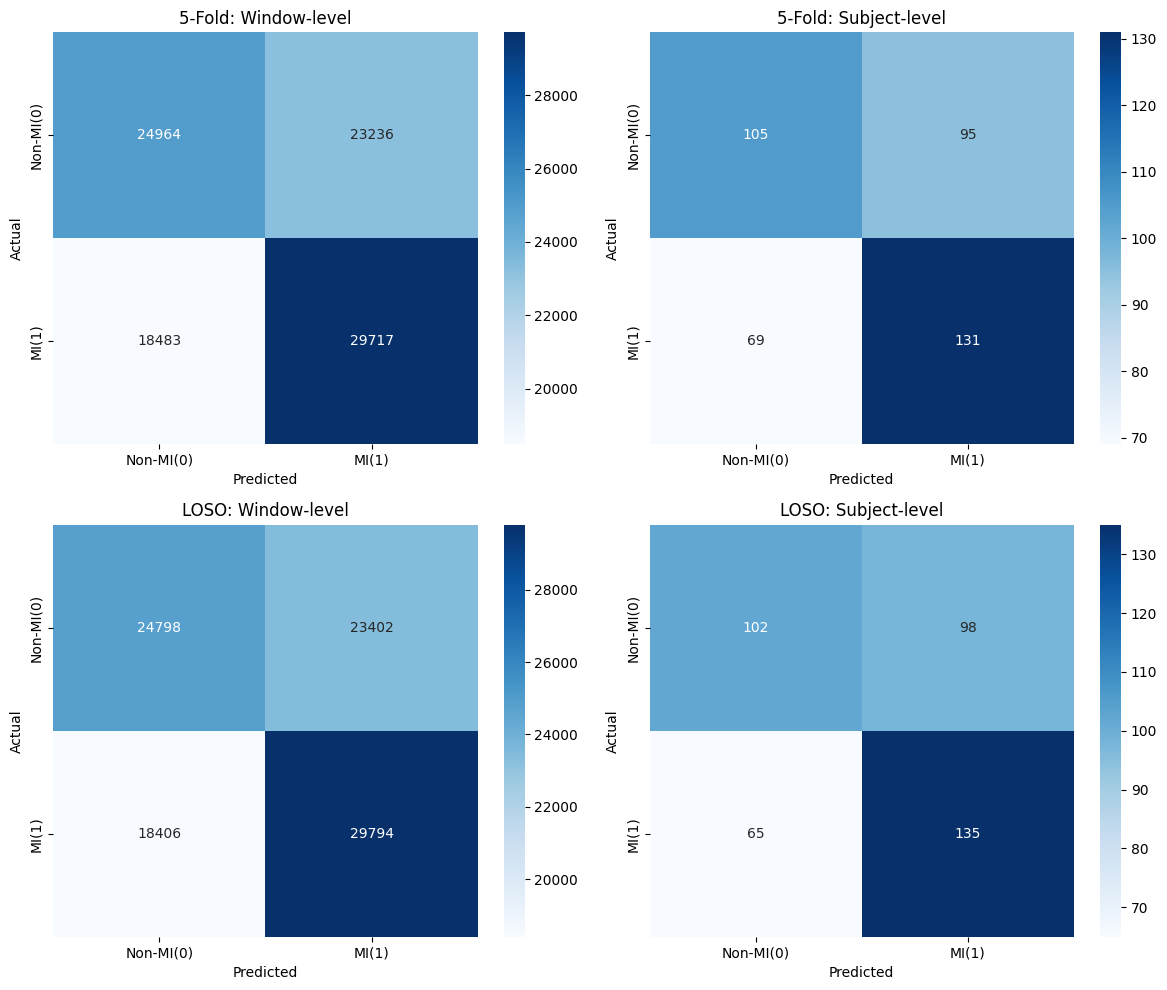

In [23]:
# 1. 整理數據
results_list = [
    ['5-Fold', 'Window'] + me_kfold_w,
    ['5-Fold', 'Subject'] + me_kfold_s,
    ['LOSO', 'Window'] + me_loso_w,
    ['LOSO', 'Subject'] + me_loso_s
]

# 2. 建立 DataFrame
columns = ['Validation_Method', 'Level', 'Accuracy', 'Sensitivity', 'Specificity', 'MCC']
summary_df = pd.DataFrame(results_list, columns=columns)
display(summary_df) # 在 Jupyter 中使用 display 比較美觀


# 4. 儲存為 CSV 檔
summary_save_path = os.path.join(save_path, "model_performance_ALL_600.csv")
summary_df.to_csv(summary_save_path, index=False, encoding='utf-8-sig')

print(f"表格已成功存檔至: {summary_save_path}")

#-----------------------------------------------------------------------------------------------------------
# 計算特徵平均重要度 (使用 LOSO 每一回合的平均)
print("\n=== 特徵重要性 (LOSO Avg Model Contribution) ===")
imp_df = pd.DataFrame({
    'Feature': feature_names, 
    'Importance': np.mean(loso_importances, axis=0)
}).sort_values(by='Importance', ascending=False)
display(imp_df.head(20))

# ==========================================
# 7. 混淆矩陣視覺化 (2x2 Grid)
# ==========================================
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# 5-Fold Window
plot_confusion_matrix(y, (kfold_probs >= 0.5).astype(int), "5-Fold: Window-level", axes[0, 0])
save_cm_to_csv(y, (kfold_probs >= 0.5).astype(int), "cm_5fold_window")
# 5-Fold Subject
y_sub_true_kfold = sub_kfold_df['Actual'].astype(int)
y_sub_pred_kfold = (sub_kfold_df['Prob'] >= 0.5).astype(int)
plot_confusion_matrix(y_sub_true_kfold, y_sub_pred_kfold, "5-Fold: Subject-level", axes[0, 1])
save_cm_to_csv(y_sub_true_kfold, y_sub_pred_kfold, "cm_5fold_subject")

# LOSO Window
plot_confusion_matrix(y, (loso_probs >= 0.5).astype(int), "LOSO: Window-level", axes[1, 0])
save_cm_to_csv(y, (loso_probs >= 0.5).astype(int), "cm_loso_window")
# LOSO Subject
y_sub_true_loso = sub_loso_df['Actual'].astype(int)
y_sub_pred_loso = (sub_loso_df['Prob'] >= 0.5).astype(int)
plot_confusion_matrix(y_sub_true_loso, y_sub_pred_loso, "LOSO: Subject-level", axes[1, 1])
save_cm_to_csv(y_sub_true_loso, y_sub_pred_loso, "cm_loso_subject")

plt.tight_layout()
plt.show()

